# Geodesics in Heat on a Grid

The squared Euclidean Gibbs kernel used by Sinkhorn is a heat kernel on a flat grid.  On a manifold, Varadhan's formula says that the short-time heat kernel carries geodesic distance information,
$$
    -4t \log h_t(x,y) \longrightarrow d(x,y)^2.
$$
The geodesics-in-heat method first diffuses a source set, then recovers an approximate distance by solving a Poisson equation driven by the normalized heat gradient.  This notebook illustrates a one-step backward-Euler resolvent approximation on a simple two-dimensional uniform grid, so the displayed parameter is the resolvent scale $\tau$ rather than the heat time $t$.


In [1]:
from pathlib import Path
import os
import sys
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse
from scipy.sparse.linalg import spsolve

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import RED, BLUE, VIOLET, GRAY, figure_dir, save_pdf, setup_matplotlib, remove_axes

setup_matplotlib()

NAME = "sinkhorn-geodesics-in-heat"
OUT = figure_dir(NAME)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)


## Discrete heat and Poisson solves

The grid Laplacian below uses reflecting, or Neumann, boundary conditions.  For each resolvent scale $\tau$, we solve a backward-Euler step
$$
    (I+\tau L)u = u_0, \qquad L \simeq -\Delta.
$$
Here $u_0$ is a narrow smooth band around a densely sampled non-convex source curve.  A single resolvent step behaves like a Laplace/Yukawa-type smoothing, while repeated steps approximate the Gaussian heat semigroup.  We then normalize the vector field $X=-\nabla u/|\nabla u|$ and solve $L\phi=-\operatorname{div}X$.  The additive constant is fixed afterwards by anchoring the distance on the source curve.


In [2]:
n = 152
x = np.linspace(0.0, 1.0, n)
h = x[1] - x[0]
Xg, Yg = np.meshgrid(x, x)


def nonconvex_source_curve(n_curve=900):
    """Strongly dimpled limacon-like closed curve, sampled densely as red dots."""
    theta = np.linspace(0.0, 2.0 * np.pi, n_curve, endpoint=False)
    r = 0.235 * (1.0 + 0.86 * np.cos(theta))
    curve = np.column_stack((
        0.44 + r * np.cos(theta),
        0.52 + 0.72 * r * np.sin(theta),
    ))
    return curve


curve = nonconvex_source_curve()
segments_a = curve
segments_b = np.roll(curve, -1, axis=0)
points = np.column_stack((Xg.ravel(), Yg.ravel()))

def distance_to_closed_polyline(points, a, b):
    dist2 = np.full(points.shape[0], np.inf)
    for p0, p1 in zip(a, b):
        v = p1 - p0
        vv = float(np.dot(v, v))
        t = np.clip(((points - p0) @ v) / vv, 0.0, 1.0)
        q = p0 + t[:, None] * v
        dist2 = np.minimum(dist2, np.sum((points - q) ** 2, axis=1))
    return np.sqrt(dist2)


def lap1d_neumann(n, h):
    main = np.full(n, 2.0 / h**2)
    off = np.full(n - 1, -1.0 / h**2)
    main[0] = main[-1] = 1.0 / h**2
    return sparse.diags([off, main, off], [-1, 0, 1], format="csr")

L1 = lap1d_neumann(n, h)
I = sparse.eye(n, format="csr")
L = sparse.kron(I, L1, format="csr") + sparse.kron(L1, I, format="csr")
Id = sparse.eye(n * n, format="csr")

# The exact field is the Euclidean distance to the continuous polyline, not only to its sample vertices.
exact = distance_to_closed_polyline(points, segments_a, segments_b).reshape(n, n)

# Smooth a narrow band around the curve before applying the resolvent.
sigma0 = 1.20 * h
u0 = np.exp(-0.5 * (exact / sigma0) ** 2)
u0 /= max(u0.max(), 1e-15)
source_mask = exact <= 1.85 * h


In [3]:
def resolvent_distance_to_set(tau):
    u = spsolve(Id + tau * L, u0.ravel()).reshape(n, n)
    uy, ux = np.gradient(u, h, h, edge_order=2)
    norm = np.sqrt(ux**2 + uy**2 + 1e-18)
    vx = -ux / norm
    vy = -uy / norm
    div = np.gradient(vx, h, axis=1, edge_order=2) + np.gradient(vy, h, axis=0, edge_order=2)

    A = L.tolil()
    b = (-div).ravel()
    # Anchor the additive nullspace at one pixel of the narrow curve band.
    anchor = int(np.argmax(u0.ravel()))
    A[anchor, :] = 0.0
    A[anchor, anchor] = 1.0
    b[anchor] = 0.0
    phi = spsolve(A.tocsr(), b).reshape(n, n)
    phi -= float(np.min(phi[source_mask]))
    phi = np.maximum(phi, 0.0)
    return phi


taus = [(0.00009, "tau-small"), (0.00032, "tau-medium"), (0.00090, "tau-large")]
approx = [(name, resolvent_distance_to_set(tau)) for tau, name in taus]

# Align the approximations to the exact scale by a robust least-square factor.
mask = (exact > 4 * h) & (exact < np.quantile(exact, 0.97))
for k, (name, phi) in enumerate(approx):
    scale = float(np.sum(exact[mask] * phi[mask]) / np.sum(phi[mask] ** 2))
    approx[k] = (name, scale * phi)


## Exported panels

The panels use the same dense non-convex source curve, while each color range is robustly normalized to reveal its own level-set geometry.  The contour values are chosen from quantiles of each displayed field, which keeps the lines approximately evenly distributed in the image instead of bunching near the farthest corners.  Larger resolvent scales $\tau$ are more stable but blur and round the geometry of the level sets.


In [4]:
cmap = LinearSegmentedColormap.from_list(
    "ot_distance", ["#ffffff", "#ead5dc", "#b98ac5", VIOLET, BLUE]
)


def panel_scale(field):
    clipped = field[np.isfinite(field)]
    vmax = float(np.quantile(clipped, 0.965))
    active = clipped[(clipped > 0.035 * vmax) & (clipped < 0.985 * vmax)]
    if active.size < 20:
        levels = np.linspace(0.10 * vmax, 0.94 * vmax, 9)
    else:
        levels = np.quantile(active, np.linspace(0.12, 0.92, 9))
        levels = np.unique(np.maximum.accumulate(levels))
        if len(levels) < 5:
            levels = np.linspace(0.10 * vmax, 0.94 * vmax, 9)
    return vmax, levels


def draw_sources(ax, *, size=1.25):
    ax.scatter(
        curve[:, 0],
        curve[:, 1],
        s=size,
        marker="o",
        color=RED,
        edgecolor="none",
        linewidth=0.0,
        zorder=5,
    )


def draw_field(field, filename):
    fig, ax = plt.subplots(figsize=(2.15, 2.15))
    vmax, levels = panel_scale(field)
    ax.imshow(
        np.minimum(field, vmax),
        origin="lower",
        extent=(0, 1, 0, 1),
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        interpolation="bilinear",
    )
    ax.contour(Xg, Yg, field, levels=levels, colors="#2d2d2d", linewidths=0.30, alpha=0.55)
    draw_sources(ax)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.018)
    plt.close(fig)

fields = [("exact", exact)] + approx
for name, field in fields:
    filename = f"{name}.pdf"
    draw_field(field, filename)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")

fig, axes = plt.subplots(1, 4, figsize=(7.6, 2.0))
for ax, (_, field) in zip(axes, fields):
    local_vmax, local_levels = panel_scale(field)
    ax.imshow(np.minimum(field, local_vmax), origin="lower", extent=(0, 1, 0, 1), cmap=cmap, vmin=0, vmax=local_vmax, interpolation="bilinear")
    ax.contour(Xg, Yg, field, levels=local_levels, colors="#2d2d2d", linewidths=0.28, alpha=0.55)
    draw_sources(ax, size=1.15)
    ax.set_aspect("equal")
    remove_axes(ax)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.02, wspace=0.03)
fig.savefig(THUMB_DIR / f"{NAME}.png", dpi=180)
plt.close(fig)


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

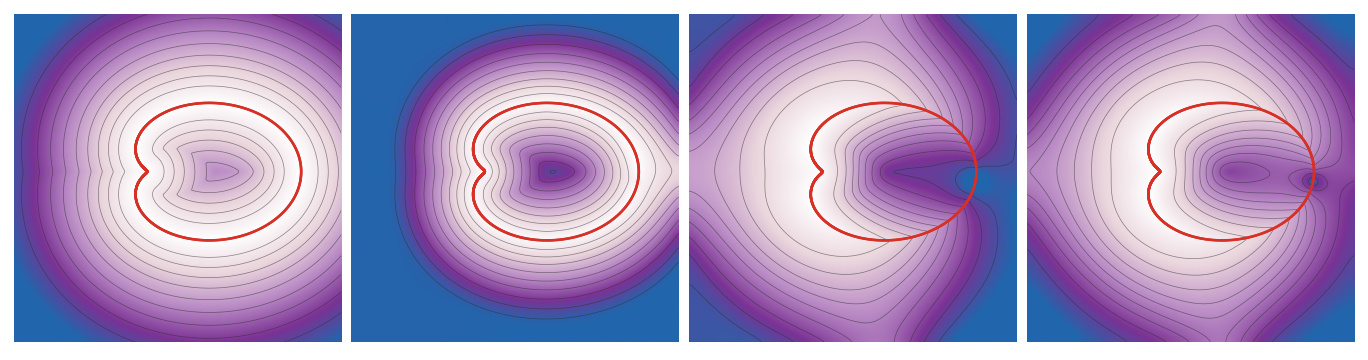

In [8]:
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-geodesics-in-heat.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-geodesics-in-heat.png")
display(Image(filename=str(_thumb)))
